Objective
The primary goal of this Exploratory Data Analysis (EDA) is to dissect the dataset to uncover the driving factors behind customer churn. Through statistical analysis and data visualization, we will identify high-risk customer segments. Finally, we will rigorously clean, format, and encode this data to lay the mathematical groundwork for the next phase: building a Machine Learning model capable of predicting churn before it happens.

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick  
%matplotlib inline
pd.set_option('display.max_columns', None)

In [3]:
churn_data = pd.read_csv ('Telco_customer_churn.csv')

In [4]:
churn_data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
churn_data.shape

(7043, 33)

In [6]:
churn_data.columns.values

array(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score',
       'CLTV', 'Churn Reason'], dtype=object)

In [7]:
churn_data.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [8]:
churn_data.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


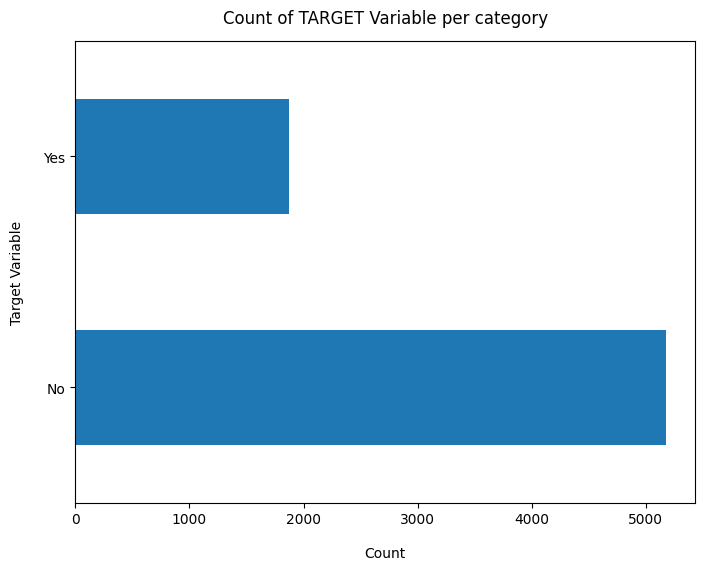

In [9]:
churn_data['Churn Label'].value_counts().plot(kind='barh', figsize=(8, 6))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);

In [10]:
churn_data['Churn Label'].value_counts()/len(churn_data['Churn Label'])*100

Churn Label
No     73.463013
Yes    26.536987
Name: count, dtype: float64

it is highlly imbalanced dataset ratio 73:26

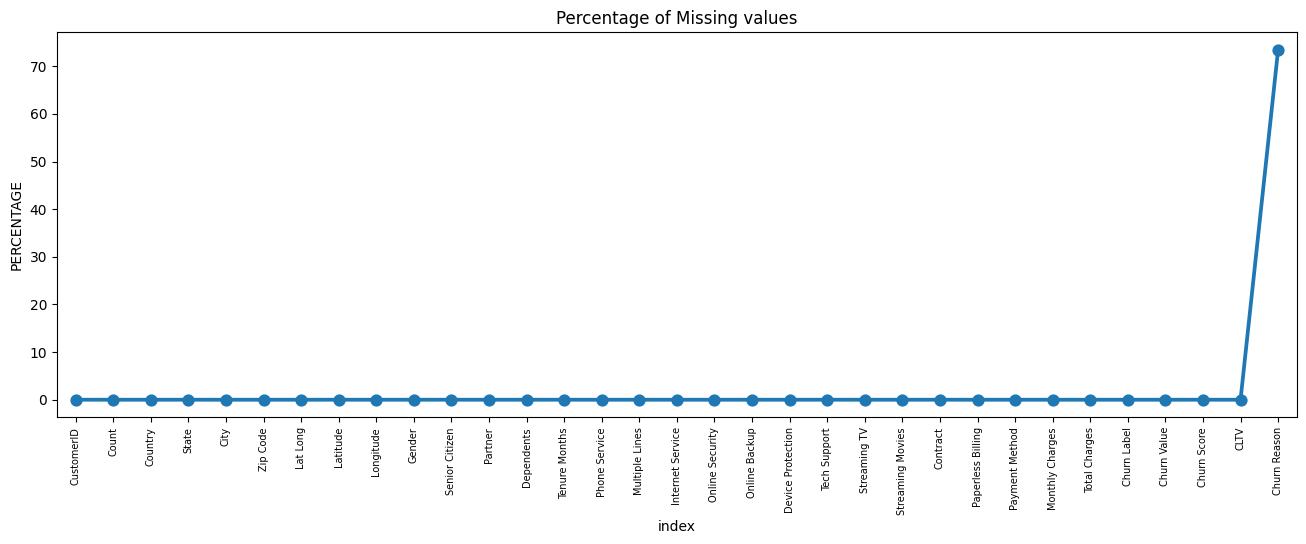

In [11]:
missing = pd.DataFrame((churn_data.isnull().sum())*100/churn_data.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

In [12]:
churn_data.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

here is the Churn Reason have more missing values but its important to check how this column  effect the target variable 

In [13]:
churn_dt = churn_data.copy()

In [14]:
churn_dt.loc[churn_dt ['Churn Reason'].isnull() == True]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
1869,7590-VHVEG,1,United States,California,Los Angeles,90001,"33.973616, -118.24902",33.973616,-118.249020,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,27,3964,NaN
1870,5575-GNVDE,1,United States,California,Los Angeles,90002,"33.949255, -118.246978",33.949255,-118.246978,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0,61,3441,NaN
1871,7795-CFOCW,1,United States,California,Los Angeles,90004,"34.076259, -118.310715",34.076259,-118.310715,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,66,4307,NaN
1872,1452-KIOVK,1,United States,California,Los Angeles,90007,"34.027337, -118.28515",34.027337,-118.285150,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,0,43,4459,NaN
1873,6713-OKOMC,1,United States,California,Los Angeles,90008,"34.008293, -118.346766",34.008293,-118.346766,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No,0,51,2013,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [15]:
churn_reasone = churn_dt.loc[churn_dt ['Churn Reason'].isnull() == False]

C:\Users\Parth Landge\AppData\Local\Temp\ipykernel_16260\3072579336.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


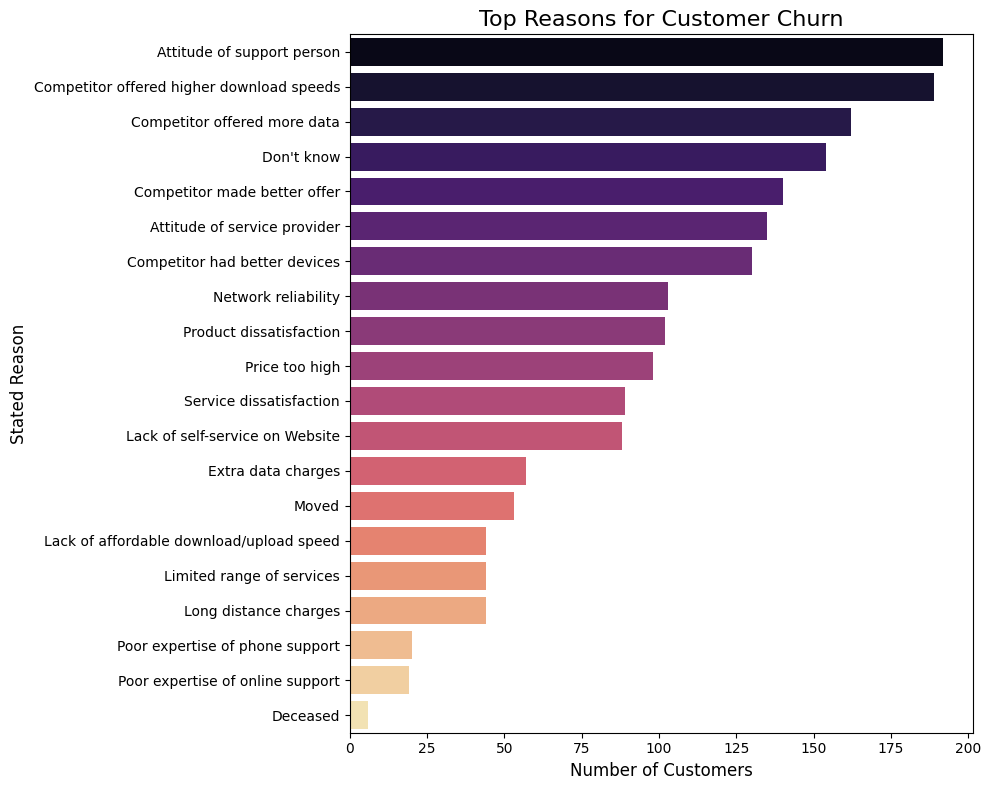

In [16]:
churned_customers = churn_data[churn_data['Churn Label'] == 'Yes']
plt.figure(figsize=(10, 8))
sns.countplot(
    y='Churn Reason', 
    data=churned_customers, 
    order=churned_customers['Churn Reason'].value_counts().index,
    palette='magma' )
plt.title('Top Reasons for Customer Churn', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Stated Reason', fontsize=12)
plt.tight_layout() 
plt.show()

we can see from the data that most of the customers, those are churned, are just because of the attitude of the support person , person or the team. So companies really need to work on this  factor because that factor is literally indivisually  causing the more impact.

**Understanding from the Graph**
The graph shows that many customers leave due to better offers from competitors, such as higher speed, more data, and attractive pricing. Competition is a major factor in customer churn.
Another important category is “Don’t know.” This does not only mean customers are confused, but it can also indicate poor feedback collection or customers leaving without giving a clear reason.
**My Suggestion**
To reduce churn, companies should improve both customer guidance and feedback systems.
Provide proper onboarding to help new customers understand services, benefits, and offers.
Maintain a support system to guide customers regularly.
Improve feedback collection so customers clearly share why they are leaving.
By doing this, companies can reduce confusion and also better understand hidden reasons behind customer churn.

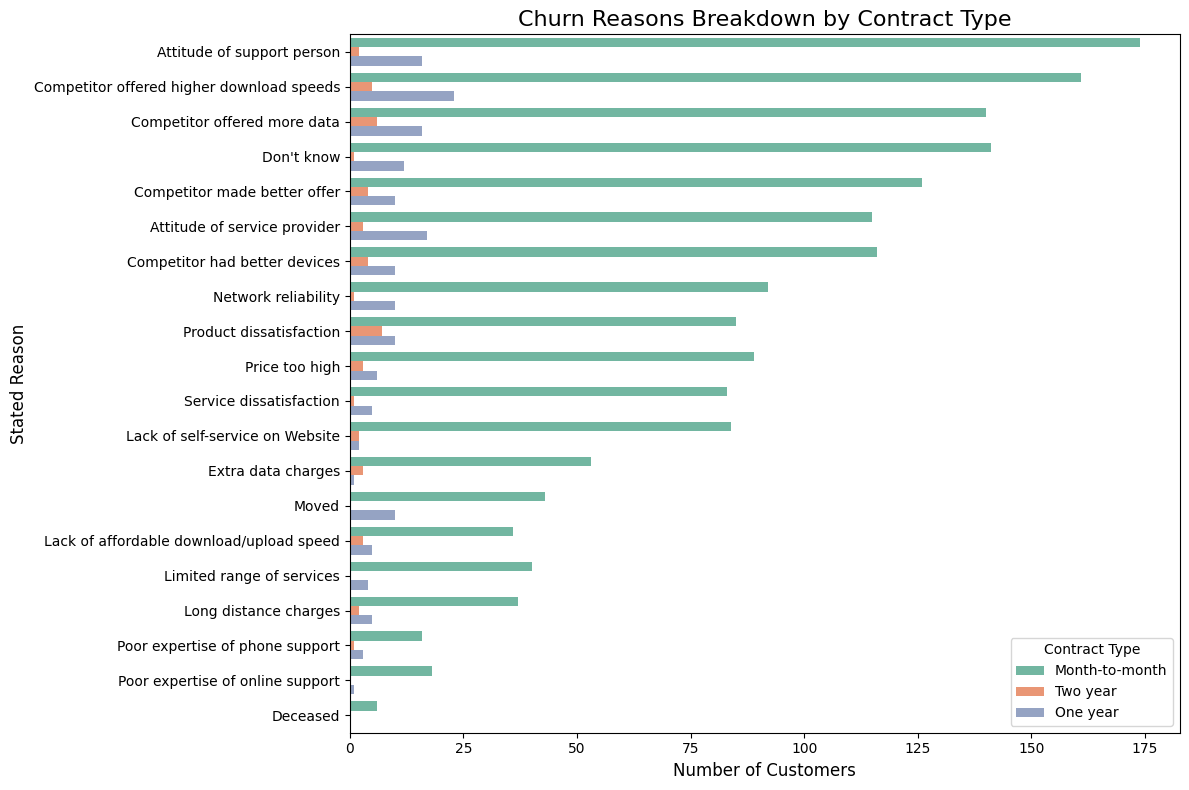

In [17]:
churned_customers = churn_data[churn_data['Churn Label'] == 'Yes']
plt.figure(figsize=(12, 8))
sns.countplot(
    y='Churn Reason', 
    hue='Contract', 
    data=churned_customers, 
    order=churned_customers['Churn Reason'].value_counts().index,
    palette='Set2')

plt.title('Churn Reasons Breakdown by Contract Type', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Stated Reason', fontsize=12)
plt.legend(title='Contract Type')
plt.tight_layout()
plt.show()

Understanding from the Graph (Churn by Contract Type)
From the graph, it is observed that month-to-month contract customers have the highest churn compared to one-year and two-year customers.
Among month-to-month users, the major reasons for churn are:
Poor attitude of the support person
Competitors offering higher download speeds
Competitors providing more data or better offers
These factors indicate that short-term customers are more sensitive to service quality and competitive advantages.
Additionally, reasons like poor expertise of phone support and online support have relatively low impact on churn, as their values are much smaller compared to other factors.
It is also clear that one-year and two-year contract customers churn less, which suggests that long-term contracts help in customer retention.

Customers with short-term (month-to-month) contracts are more likely to churn, mainly due to service experience and better competitor offers, while long-term contracts improve customer retention.

In [18]:
print(churn_dt['Tenure Months'].max()) 

72


In [19]:
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]
churn_dt['tenure_group'] = pd.cut(churn_dt['Tenure Months'], range(1, 80, 12), right=False, labels=labels)

In [20]:
churn_dt.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,tenure_group
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1 - 12
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1 - 12
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,1 - 12
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25 - 36
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,49 - 60


In [21]:
churn_dt.drop(columns= ['CustomerID','Tenure Months'], axis=1, inplace=True)
churn_dt.head()

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,tenure_group
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1 - 12
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1 - 12
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved,1 - 12
3,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25 - 36
4,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices,49 - 60


**analyzing of each feature with target column**

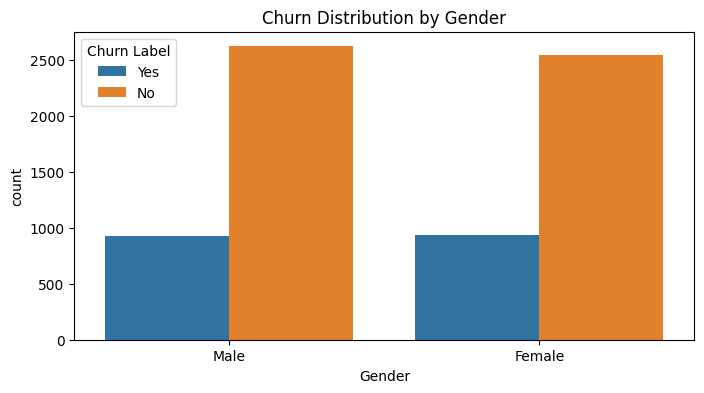

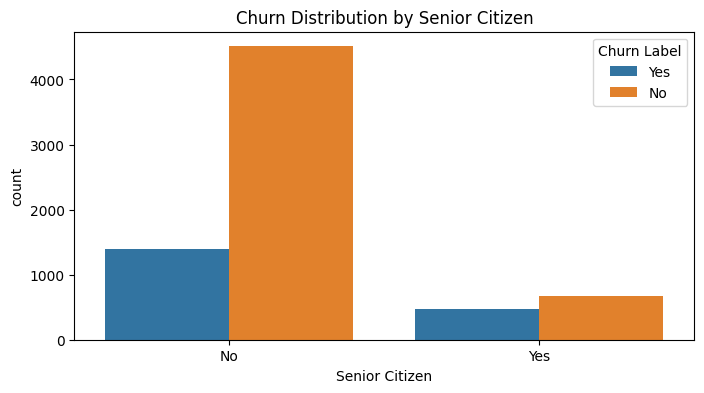

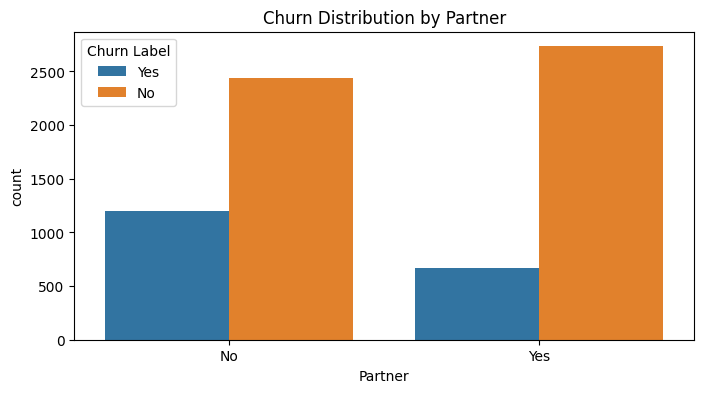

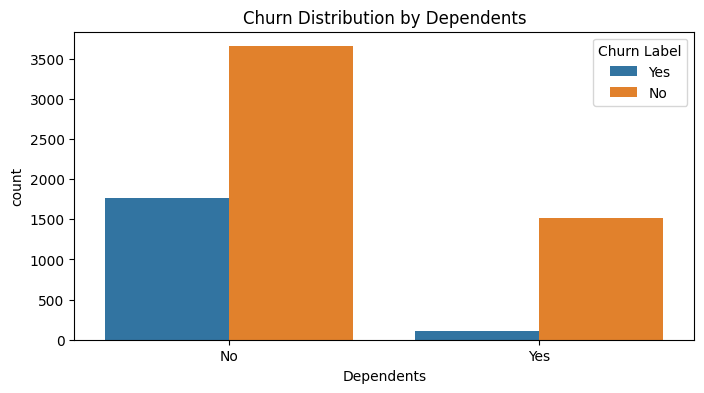

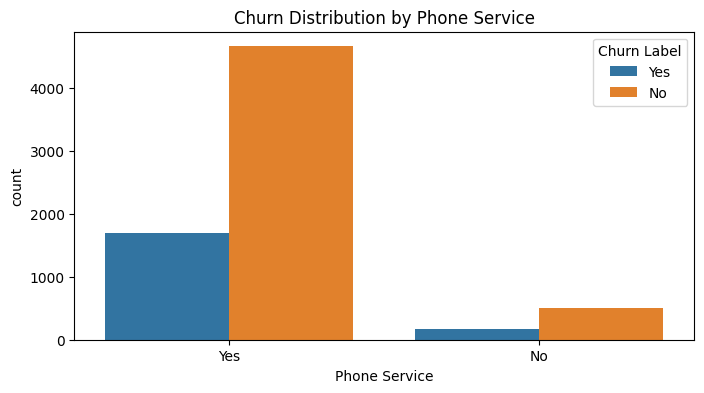

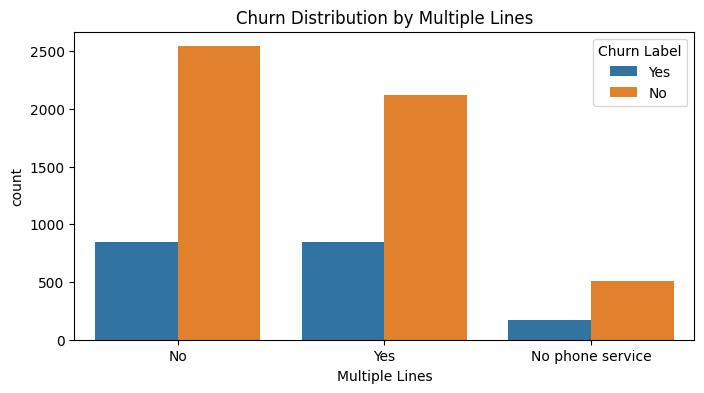

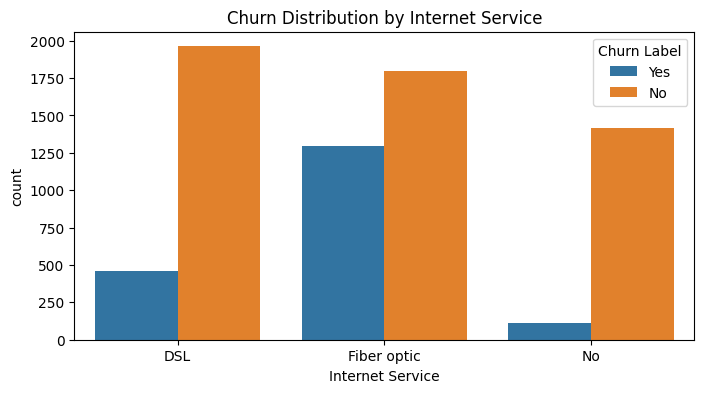

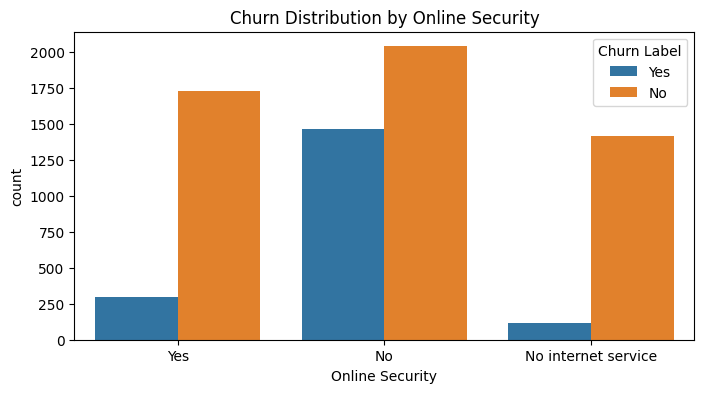

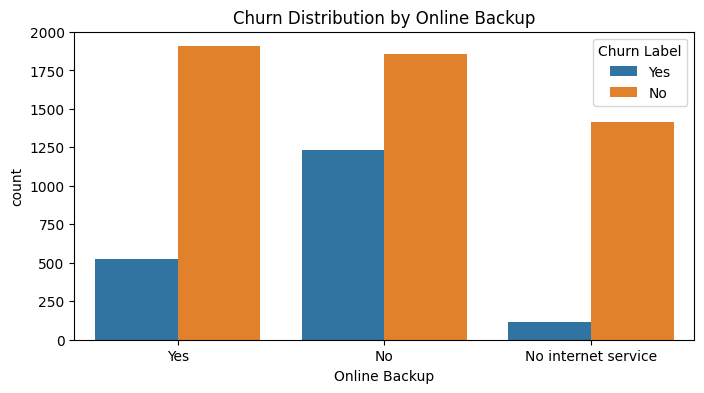

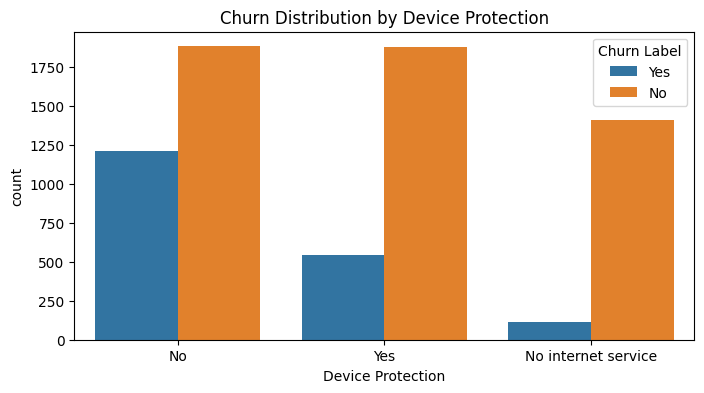

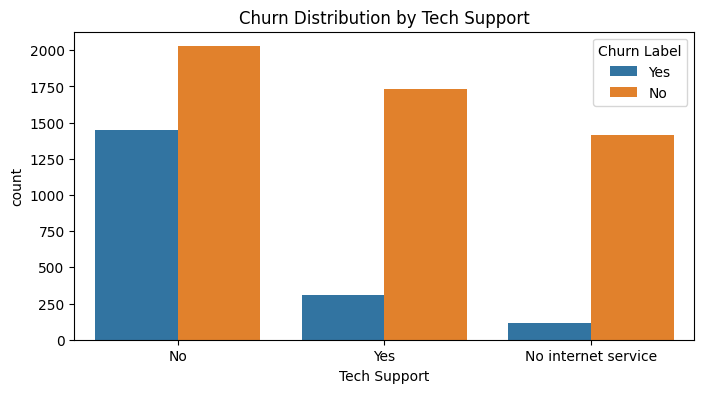

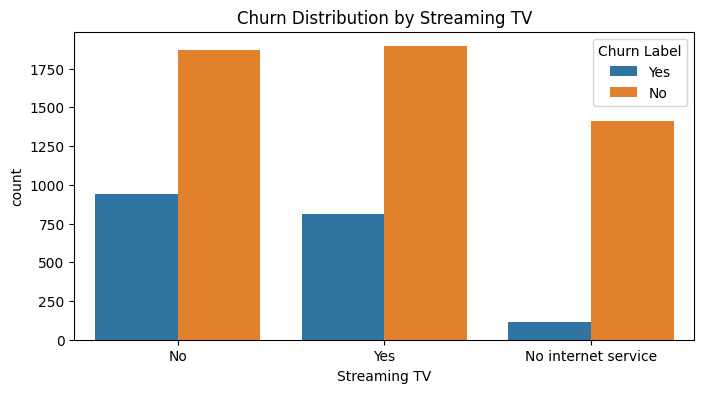

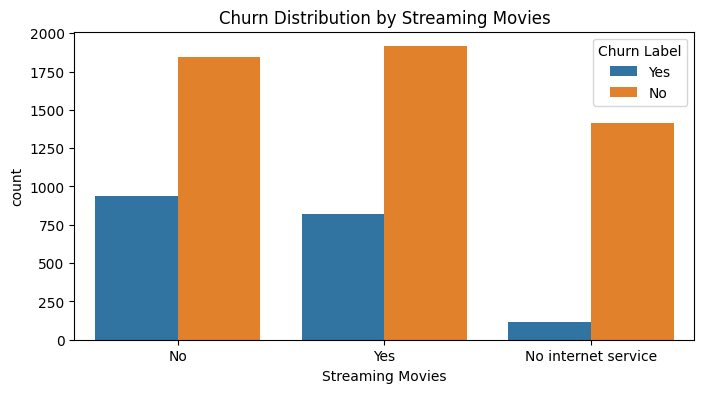

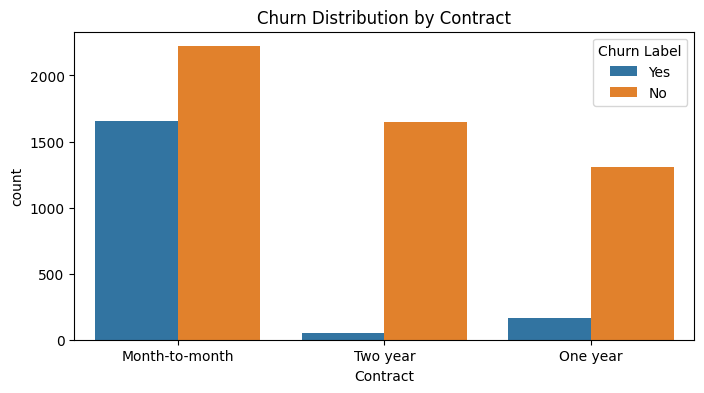

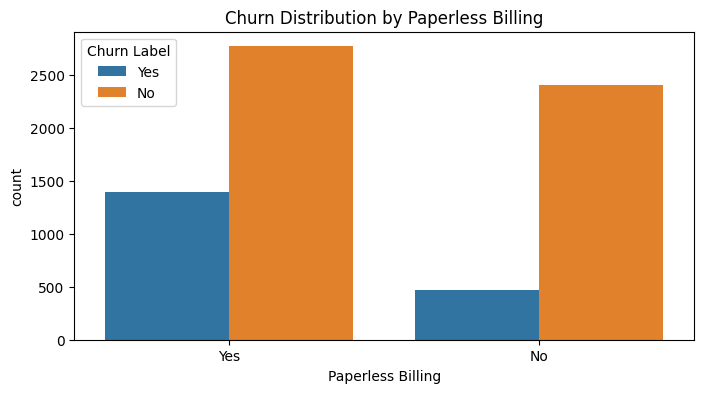

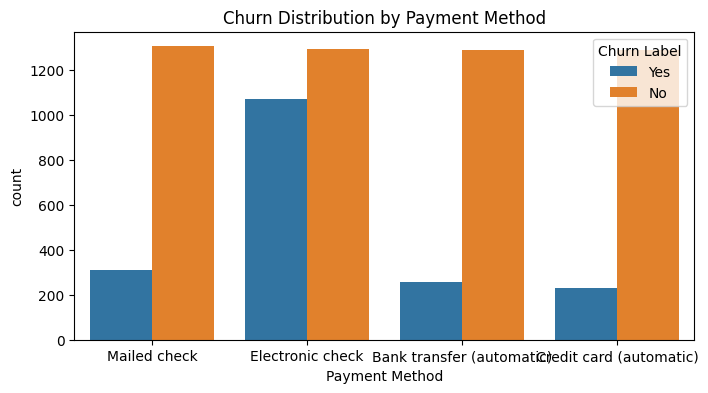

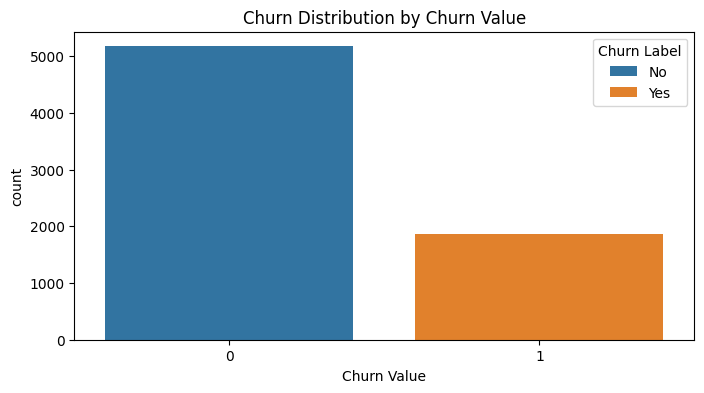

In [22]:
columns_to_ignore = ['Churn Label', 'Total Charges', 'Monthly Charges']

for i, predictor in enumerate(churn_dt.drop(columns=columns_to_ignore)):
    if 1 < churn_dt[predictor].nunique() < 6:
        
        plt.figure(figsize=(8, 4))
        sns.countplot(data=churn_dt, x=predictor, hue='Churn Label')
        plt.title(f'Churn Distribution by {predictor}')
        plt.show()

since the we have alredy study the churn reason feature and it has more than 60 percent null values we will drop that and also churn score and churn label 

In [23]:
churn_dt = churn_dt.drop(['Churn Reason','Churn Score','Churn Label'],axis = 1)

In [24]:
churn_dt['Churn Value'].unique()

array([1, 0])

In [25]:
churn_dt['Churn Value'].value_counts()/len(churn_dt['Churn Value'])*100

Churn Value
0    73.463013
1    26.536987
Name: count, dtype: float64

In [26]:
columns_to_drop = ['CustomerID', 'Lat Long', 'Churn Reason', 'City', 'Count', 'Churn Label', 'Zip Code' ]
churn_dt = churn_dt.drop(columns=columns_to_drop, errors='ignore')
churn_dt['Total Charges'] = pd.to_numeric(churn_dt['Total Charges'], errors='coerce')
churn_dt['Total Charges'] = churn_dt['Total Charges'].fillna(0) 

categorical_cols = churn_dt.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(churn_dt, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)

(7043, 34)


In [27]:
df_encoded

,Latitude,Longitude,Monthly Charges,Total Charges,Churn Value,CLTV,tenure_group,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,Online Security_Yes,Online Backup_No internet service,Online Backup_Yes,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,33.964131,-118.272783,53.85,108.15,1,3239,1 - 12,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,34.059281,-118.307420,70.70,151.65,1,2701,1 - 12,False,False,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
2,34.048013,-118.293953,99.65,820.50,1,5372,1 - 12,False,False,False,True,True,False,True,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False
3,34.062125,-118.315709,104.80,3046.05,1,5003,25 - 36,False,False,True,True,True,False,True,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False
4,34.039224,-118.266293,103.70,5036.30,1,5340,49 - 60,True,False,False,True,True,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,34.341737,-116.539416,21.15,1419.40,0,5306,61 - 72,False,False,False,False,True,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False,False
7039,34.667815,-117.536183,84.80,1990.50,0,2140,13 - 24,True,False,True,True,True,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True
7040,34.559882,-115.637164,103.20,7362.90,0,5560,61 - 72,False,False,True,True,True,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,True,False,True,True,False,False
7041,34.167800,-116.864330,29.60,346.45,0,2793,1 - 12,False,False,True,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


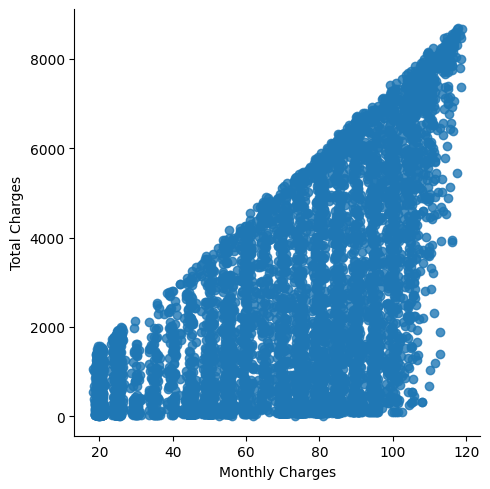

In [28]:
sns.lmplot(data=df_encoded, x='Monthly Charges', y='Total Charges', fit_reg=False)

as total charges increses monthly charges also increses

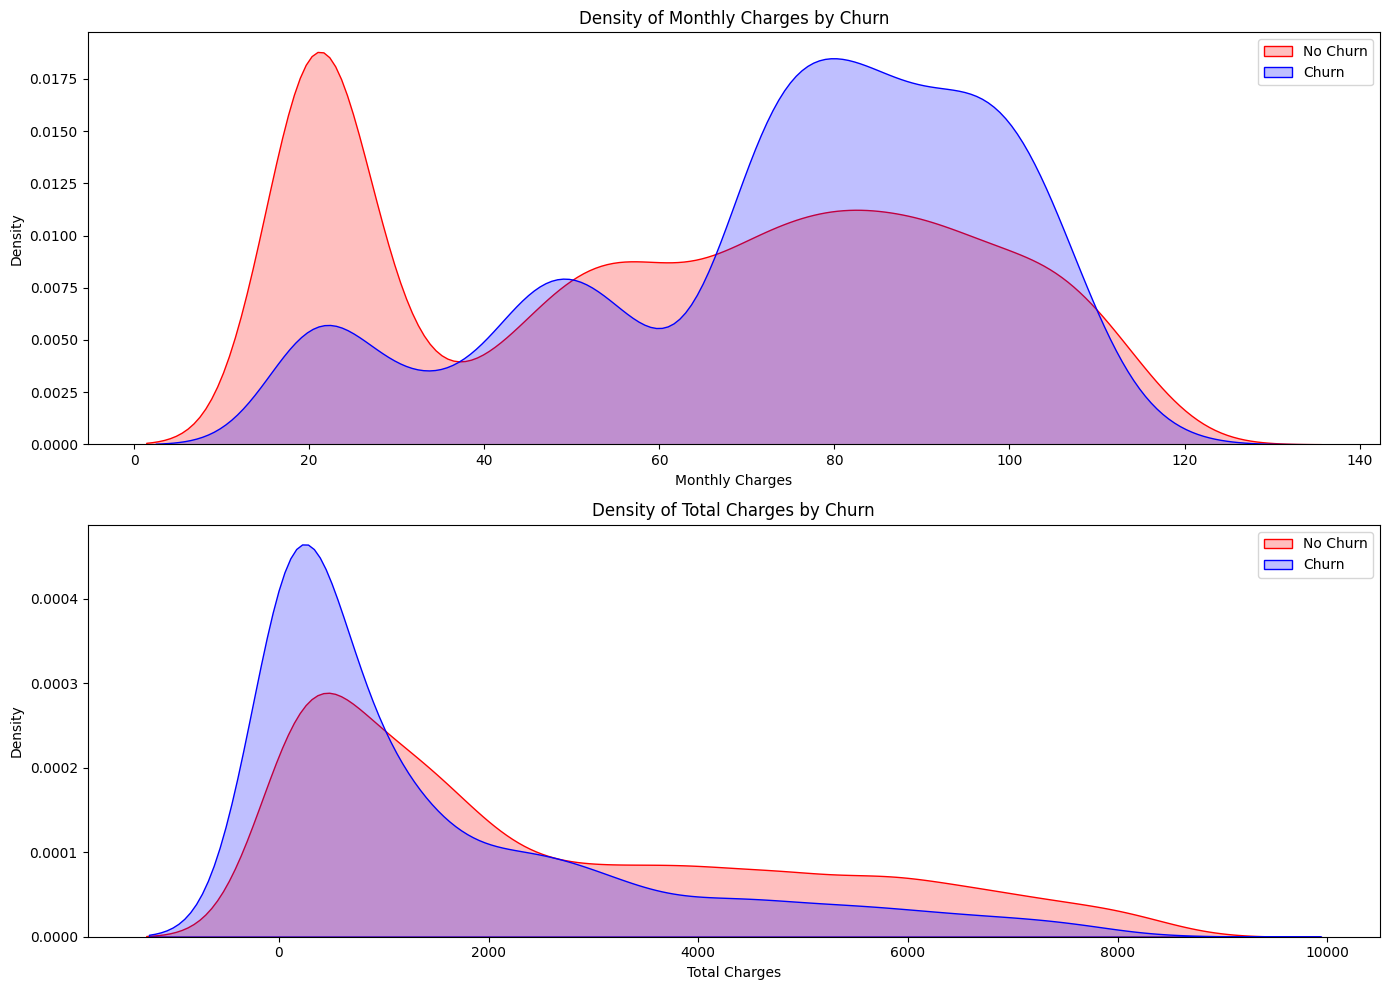

In [29]:
cols_to_plot = [ 'Monthly Charges', 'Total Charges']
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes = axes.flatten() 

for i, col in enumerate(cols_to_plot):
    sns.kdeplot(data=df_encoded[df_encoded['Churn Value'] == 0][col], 
                color="red", fill=True, ax=axes[i], label="No Churn")
    
    sns.kdeplot(data=df_encoded[df_encoded['Churn Value'] == 1][col], 
                color="blue", fill=True, ax=axes[i], label="Churn")
    axes[i].set_title(f'Density of {col} by Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

1. Insight: Monthly Charges vs. Churn
Observation: The density of non-churning customers peaks heavily at lower monthly charges . Conversely, the density of churning customers peaks dramatically at higher monthly charges .
Conclusion: There is a strong positive correlation between high monthly charges and churn rate. Customers on cheaper plans exhibit high loyalty, while expensive plans are a major pain point driving customers to leave.
2. Insight: Total Charges vs. Churn
Observation: Both churn and non-churn distributions are heavily right-skewed, peaking at lower total charges (under $2,000). However, at the higher end of total charges , the density of non-churners is visibly higher than churners.

Conclusion: Most churn happens early in the customer lifecycle (when total accumulated charges are low). High total charges strongly indicate a long-tenured customer, and these long-term customers are significantly less likely to churn.

In [30]:
tenure_mapping = {'1 - 12': 0, '13 - 24': 1,'25 - 36': 2, '37 - 48': 3,'49 - 60': 4,'61 - 72': 5}
df_encoded['tenure_group_encoded'] = df_encoded['tenure_group'].map(tenure_mapping)

df_encoded = df_encoded.drop('tenure_group', axis=1)

<Axes: >

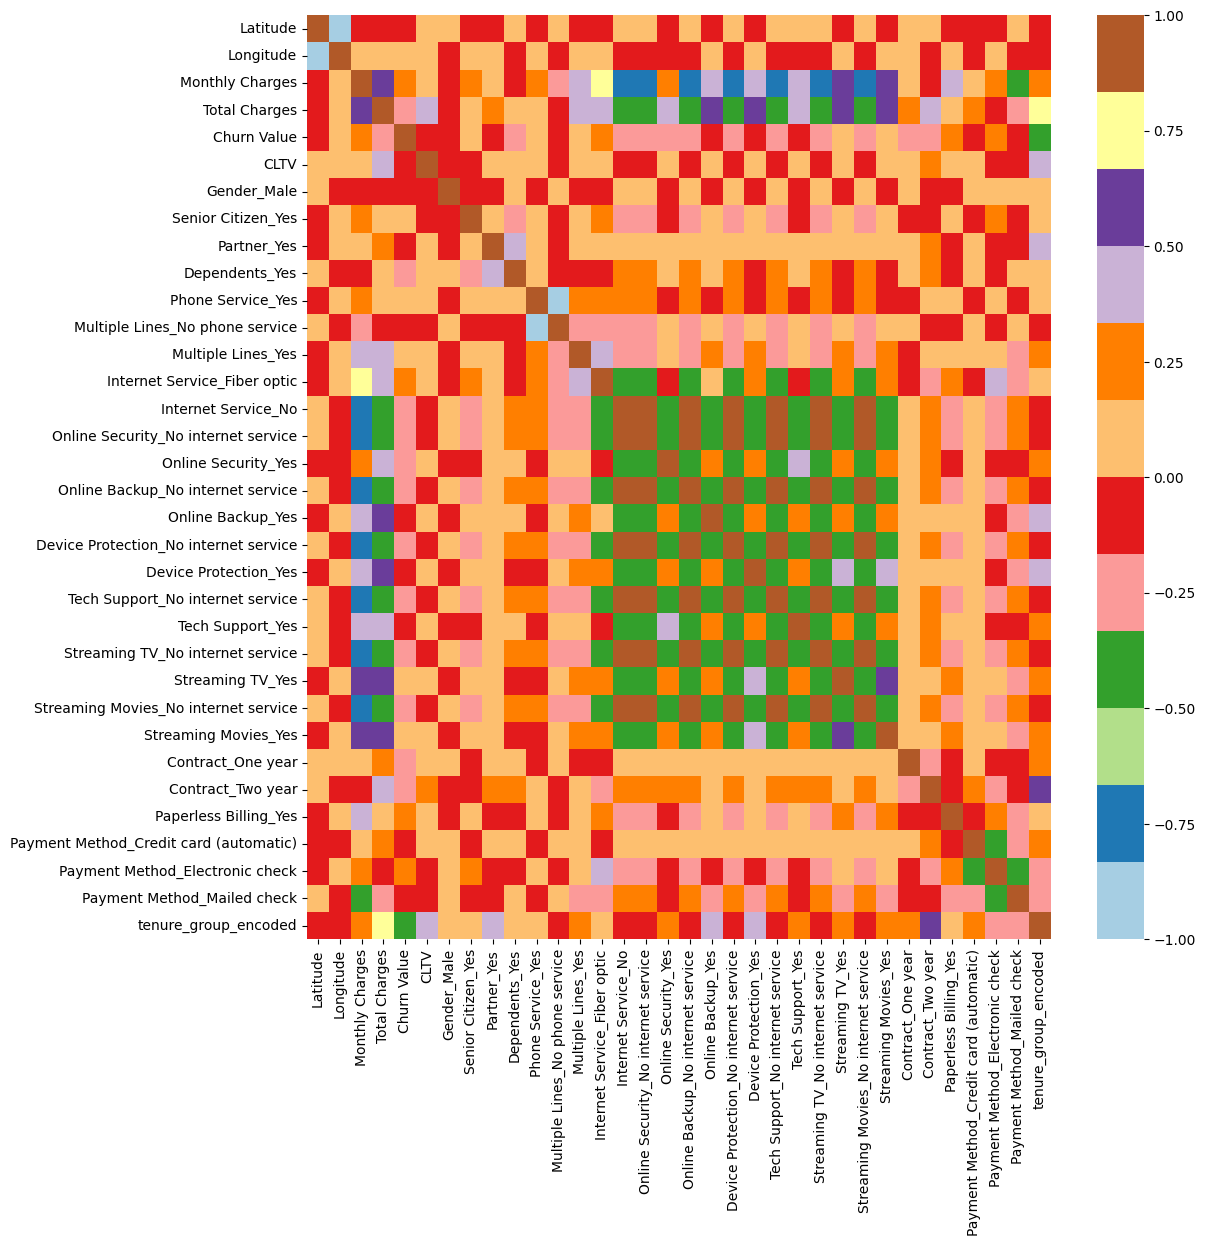

In [31]:
plt.figure(figsize=(12,12))
sns.heatmap(df_encoded.corr(), cmap="Paired")

bivarate analysis 

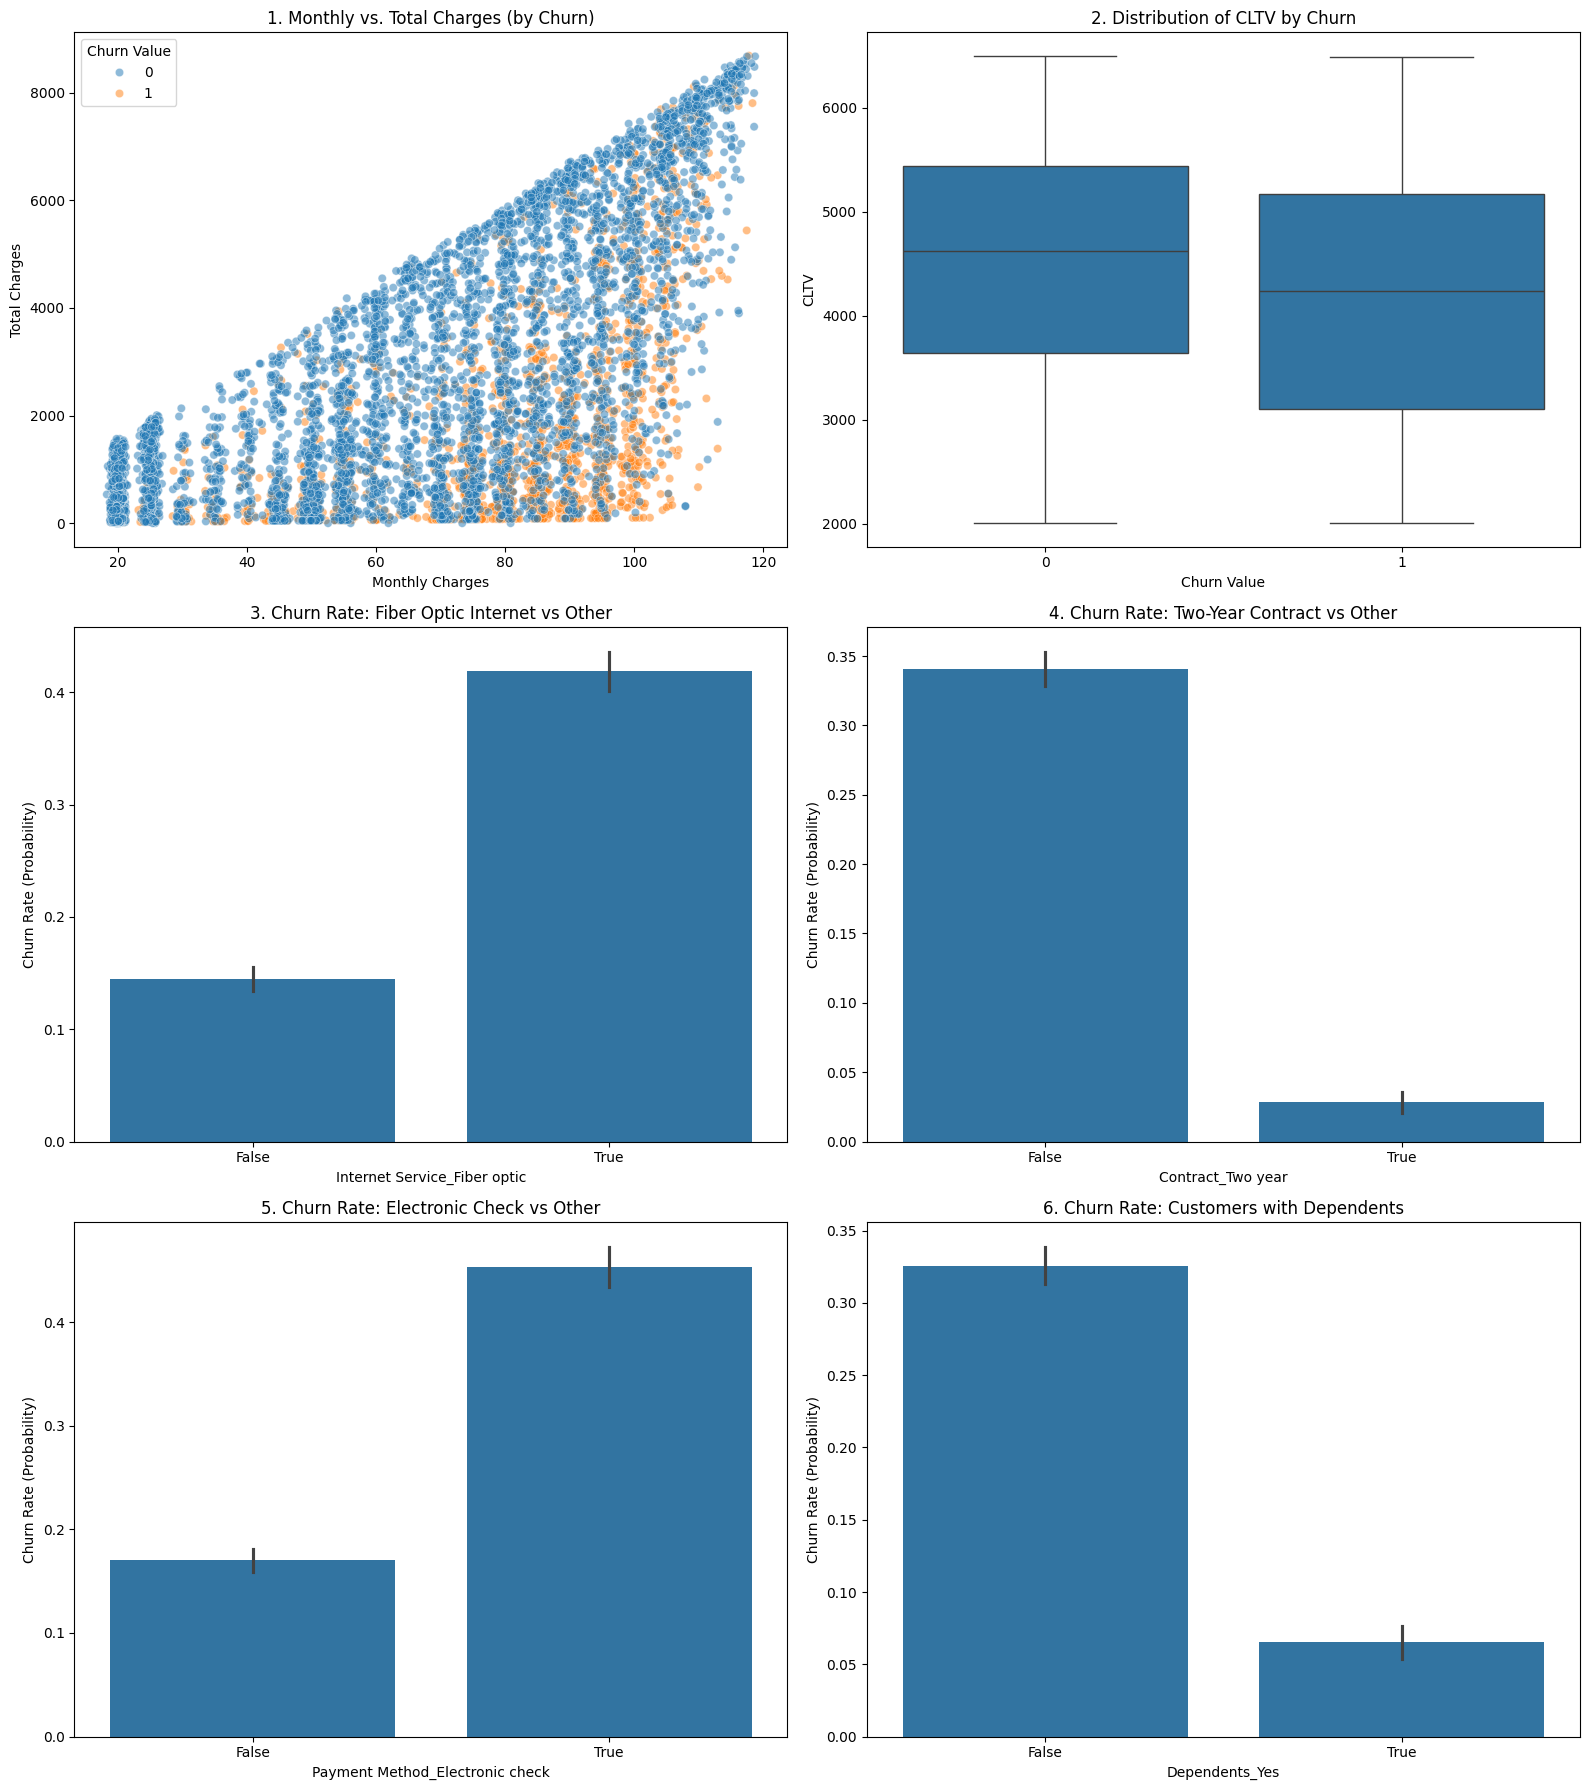

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten() 

sns.scatterplot(data=df_encoded, x='Monthly Charges', y='Total Charges', 
                hue='Churn Value', alpha=0.5, ax=axes[0])
axes[0].set_title('1. Monthly vs. Total Charges (by Churn)')

sns.boxplot(data=df_encoded, x='Churn Value', y='CLTV', ax=axes[1])
axes[1].set_title('2. Distribution of CLTV by Churn')
sns.barplot(data=df_encoded, x='Internet Service_Fiber optic', y='Churn Value', ax=axes[2])
axes[2].set_title('3. Churn Rate: Fiber Optic Internet vs Other')
axes[2].set_ylabel('Churn Rate (Probability)')

sns.barplot(data=df_encoded, x='Contract_Two year', y='Churn Value', ax=axes[3])
axes[3].set_title('4. Churn Rate: Two-Year Contract vs Other')
axes[3].set_ylabel('Churn Rate (Probability)')

sns.barplot(data=df_encoded, x='Payment Method_Electronic check', y='Churn Value', ax=axes[4])
axes[4].set_title('5. Churn Rate: Electronic Check vs Other')
axes[4].set_ylabel('Churn Rate (Probability)')

sns.barplot(data=df_encoded, x='Dependents_Yes', y='Churn Value', ax=axes[5])
axes[5].set_title('6. Churn Rate: Customers with Dependents')
axes[5].set_ylabel('Churn Rate (Probability)')

plt.tight_layout()
plt.show()

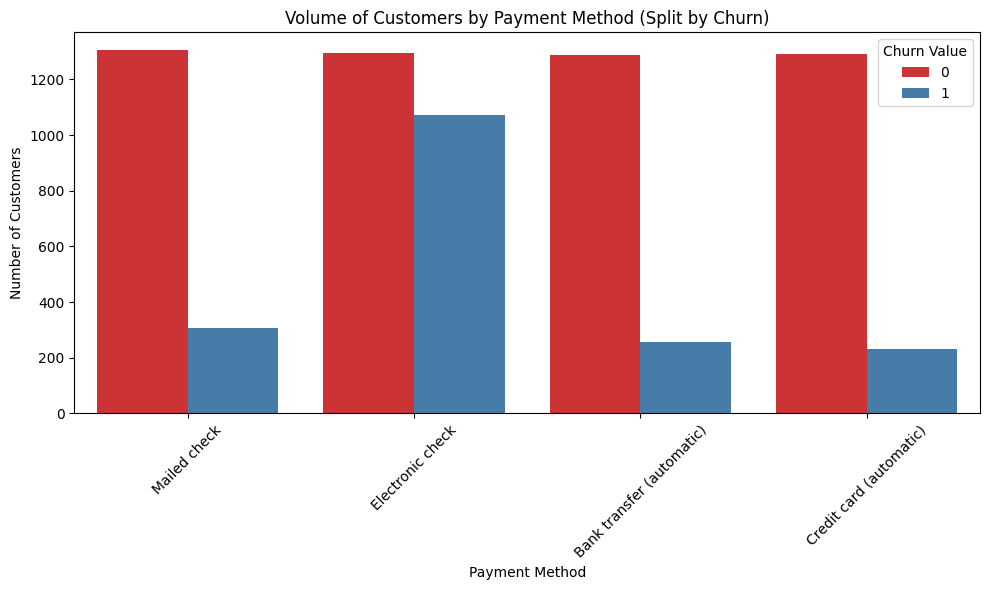

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(data=churn_data, x='Payment Method', hue='Churn Value', palette='Set1')
plt.title('Volume of Customers by Payment Method (Split by Churn)')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

In [34]:
df_encoded

,Latitude,Longitude,Monthly Charges,Total Charges,Churn Value,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,Online Security_Yes,Online Backup_No internet service,Online Backup_Yes,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,tenure_group_encoded
0,33.964131,-118.272783,53.85,108.15,1,3239,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,0
1,34.059281,-118.307420,70.70,151.65,1,2701,False,False,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0
2,34.048013,-118.293953,99.65,820.50,1,5372,False,False,False,True,True,False,True,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,0
3,34.062125,-118.315709,104.80,3046.05,1,5003,False,False,True,True,True,False,True,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True,False,2
4,34.039224,-118.266293,103.70,5036.30,1,5340,True,False,False,True,True,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,True,False,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,34.341737,-116.539416,21.15,1419.40,0,5306,False,False,False,False,True,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True,True,False,False,False,5
7039,34.667815,-117.536183,84.80,1990.50,0,2140,True,False,True,True,True,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True,1
7040,34.559882,-115.637164,103.20,7362.90,0,5560,False,False,True,True,True,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,True,False,True,True,False,False,5
7041,34.167800,-116.864330,29.60,346.45,0,2793,False,False,True,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0


EDA Conclusion & Business Insights
Data Quality & Target Distribution

Imbalanced Dataset: The target variable (Churn Value) is moderately imbalanced, with an approximate 74:26 ratio (74% Non-Churners vs. 26% Churners). This imbalance will need to be addressed during the model training phase.

Data Cleaning: The Churn Reason column contained a high volume of missing values. Because it also represents "target leakage" (data only known after a churn event occurs), it was safely dropped to prevent model bias.

Demographic Insights

Gender is Neutral: The distribution of churners and non-churners is nearly identical across both Male and Female demographics, indicating that gender is not a predictive driver of churn.

Family & Partners: Customers without partners exhibit a significantly higher churn rate compared to those with partners.

Age Factor: While they make up a smaller portion of the total customer base, Senior Citizens churn at a notably higher probability than younger customers.

Services & Account Setup

The "Sticky" Services: Customers who subscribe to Tech Support and traditional Phone Services are highly loyal and churn at much lower rates.

Internet Dependencies: Interestingly, customers who do not have any internet service at all represent the safest, lowest-churn segment.

Payment Friction: The Electronic Check payment method is a massive red flag. Customers using this method churn at drastically higher rates than those using automatic credit card payments or bank transfers.

In [35]:
df_encoded.to_csv('df.csv')